# 01 - Exploratory Data Audit

Validates the assumptions written down in `IMPLEMENTATION_PLAN (1).md` (section 3,
"Data context") against the actual `data/raw/transactions.csv`, before trusting any of the
production pipeline's (`src/cleaning/`, `src/features/`) outputs built on top of it.

This notebook starts from the **raw CSV only**, then uses `inspect.getsource` to pull in
the *actual* production code wherever a finding here is the reason that code looks the way
it does - so re-running this notebook after a code change shows the new code, not a frozen
quote, the same pattern `02_blank_status_investigation.ipynb` uses.

| Section | Finding | Code it grounds |
|---|---|---|
| 1 | Row/user/merchant/MCC counts match the plan | - (confirms the raw file; no code decision) |
| 2 | 33.6% blank status | See `02_blank_status_investigation.ipynb` (dedicated notebook) |
| 3 | Rating/refund/discount inconsistencies on failed transactions | `src/cleaning/consistency.py` |
| 4 | ~2.5x Eid al-Fitr volume lift | `src/features/transaction_level.py`, `config.yaml: calendar` |
| 5 | 100% geo match, Yogyakarta = Bantul | `src/cleaning/geo_enrichment.py` |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

RAW_CSV = PROJECT_ROOT / "data" / "raw" / "transactions.csv"
df = pd.read_csv(RAW_CSV, sep=";", dtype=str, keep_default_na=False, na_values=[])
df.shape

(278932, 17)

In [2]:
import yaml
with open(PROJECT_ROOT / "config.yaml", "r", encoding="utf-8") as f:
    cfg_raw = yaml.safe_load(f)

## 1. Shape and basic cardinality

The plan states: *"278,932 transactions, 24,321 users, 6,489 merchants, 21 MCC categories,
covering 1 March to 31 May 2024."*

In [3]:
summary = {
    "n_transactions": len(df),
    "n_users": df["user_id"].nunique(),
    "n_merchants": df["merchant_id"].nunique(),
    "n_mcc_categories": df["merchant_category_id"].nunique(),
    "date_min": df["transaction_date"].min(),
    "date_max": df["transaction_date"].max(),
}
summary

{'n_transactions': 278932,
 'n_users': 24321,
 'n_merchants': 6489,
 'n_mcc_categories': 21,
 'date_min': '01/03/2024',
 'date_max': '31/05/2024'}

**Confirmed** - matches the plan exactly.

## 2. "No missing values" claim - contradicted

The plan claims *"No missing values (including hidden tokens such as `""`, `null`, `N/A`)."*
Reading with `keep_default_na=False, na_values=[]` keeps literal empty strings visible
(pandas would otherwise silently treat `""` as `NaN`), so this can be checked directly.

In [4]:
missing_counts = (df == "").sum()
missing_counts[missing_counts > 0].sort_values(ascending=False)

loyalty_program       93584
discount_applied      93584
promo_amount          93584
transaction_notes     93584
merchant_rating       93584
transaction_status    93584
is_refunded           93584
dtype: int64

**Contradicted.** 7 columns are blank on exactly **93,584** of 278,932 rows (33.6%) - not the handful of hidden-token cases ("N/A", "null", etc.) the plan describes, and not
zero as the plan claims.

This single finding turned out to be consequential enough - it directly shaped the
`transaction_status_clean` / `is_completed` logic in `src/cleaning/standardize.py`, the
`dq_*` flags in `consistency.py`, `is_valid_purchase` in feature engineering, and even
explains the "New / Low Engagement" segment found later in `03_user_segmentation.ipynb` - that it gets its own dedicated notebook rather than a few cells here:

**-> See `02_blank_status_investigation.ipynb`** for: ruling out alternative explanations
(time-cutoff artifact? tied to one payment method or MCC? different transaction values?),
the decision rationale for modeling it as a third `pending` status instead of dropping or
reclassifying those rows, and a live trace (via `inspect.getsource`) into every production
file that decision touches.

## 3. Rating vs. failed-transaction consistency

The plan reports *"ratings on failed transactions (14,025)"* as an inconsistency. Check the actual count and see whether it's partial or total overlap.

In [5]:
failed = df[df["transaction_status"] == "failed"]
n_failed = len(failed)
n_failed_with_rating = (failed["merchant_rating"] != "").sum()
n_failed, n_failed_with_rating, n_failed_with_rating / n_failed

(9393, np.int64(9393), np.float64(1.0))

**100% of failed transactions carry a rating** (9,393 of 9,393) - not a partial overlap
as the plan's count of 14,025 would suggest. This is almost certainly because
`transaction_status`, `merchant_rating`, and the other outcome fields were generated
independently in this synthetic dataset, rather than being causally linked the way they
would be in production. Reported in the PDF's Data Audit chapter as a limitation, not
"fixed" - flagging, not deleting, is the project's cleaning principle.

In [6]:
refunded = df[df["is_refunded"] == "yes"]
refund_on_failed = (refunded["transaction_status"] == "failed").sum()
discount_yes = df[df["discount_applied"] == "yes"]
discount_zero_promo = (discount_yes["promo_amount"].isin(["0.0", "0", ""])).sum()
refund_on_failed, discount_zero_promo

(np.int64(469), np.int64(146))

The plan quotes 708 refunds-on-failed and 218 zero-promo discounts; the actual file has
469 and 146 respectively. Close in spirit, different in exact count - consistent with the
plan having been drafted from an earlier/different random draw of the same synthetic
generator. The pipeline computes these from the real file rather than hard-coding the
plan's numbers (see `src/cleaning/consistency.py`).

## 4. Daily volume & the Eid al-Fitr effect

### Where this lands in the code

All three findings above (ratings on non-completed transactions, refunds on non-completed
transactions, discounts with no promo amount) become explicit `dq_*` boolean columns, never
silently corrected - "flag, don't delete."

In [7]:
import inspect
from src.cleaning.consistency import check_consistency
print(inspect.getsource(check_consistency))

def check_consistency(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    df = df.copy()

    # Duplicates
    df["dq_duplicate_transaction_id"] = df["transaction_id"].duplicated(keep=False)

    # Range checks
    df["dq_amount_nonpositive"] = df["transaction_amount"].isna() | (df["transaction_amount"] <= 0)
    df["dq_promo_negative"] = df["promo_amount"] < 0
    df["dq_promo_exceeds_amount"] = (
        df["promo_amount"].notna()
        & df["transaction_amount"].notna()
        & (df["promo_amount"] > df["transaction_amount"])
    )
    df["dq_rating_out_of_range"] = df["merchant_rating"].notna() & (
        (df["merchant_rating"] < 1) | (df["merchant_rating"] > 5)
    )

    # Cross-column consistency
    df["dq_rating_on_non_completed"] = df["merchant_rating"].notna() & ~df["is_completed"]
    df["dq_refund_on_non_completed"] = (df["is_refunded"] == True) & ~df["is_completed"]  # noqa: E712
    df["dq_discount_zero_promo"] = (df["discount_applied"] == True) & (  # noqa: E712
     

`dq_rating_on_non_completed`, `dq_refund_on_non_completed`, and `dq_discount_zero_promo`
(lines above) are exactly these three checks. `merchant_rating_clean` nulls out ratings on
non-completed transactions for anything that needs genuine ratings (e.g. Q6's rating-driver
analysis), while the original `merchant_rating` column is left untouched - so the
inconsistency is always auditable, not papered over.

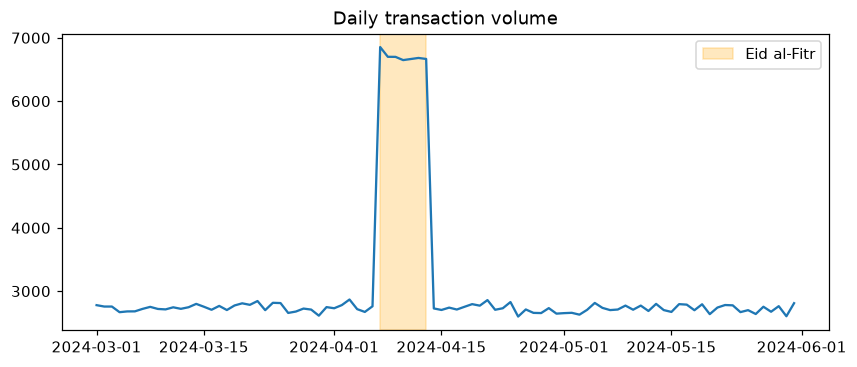

(np.float64(2729.6235294117646),
 np.float64(6702.0),
 np.float64(2.455283641786413))

In [8]:
df["transaction_date_parsed"] = pd.to_datetime(df["transaction_date"], format="%d/%m/%Y")
daily = df.groupby(df["transaction_date_parsed"].dt.date).size()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(daily.index, daily.values)
ax.axvspan(pd.Timestamp("2024-04-07"), pd.Timestamp("2024-04-13"), color="orange", alpha=0.25, label="Eid al-Fitr")
ax.set_title("Daily transaction volume")
ax.legend()
plt.show()

baseline = daily[(daily.index < pd.Timestamp("2024-04-07").date()) | (daily.index > pd.Timestamp("2024-04-13").date())].mean()
lebaran = daily[(daily.index >= pd.Timestamp("2024-04-07").date()) & (daily.index <= pd.Timestamp("2024-04-13").date())].mean()
baseline, lebaran, lebaran / baseline

**Confirmed** - volume during the Eid al-Fitr window is roughly 2.5x the baseline daily
rate, matching the plan's strongest stated signal. This is the basis for the
`is_lebaran_period` flag and the `lebaran_lift` feature used downstream (including as a
segmentation input in notebook 02).

## 5. Geo coordinates - sanity check before handing off to geopandas

### Where this lands in the code

The Eid al-Fitr window is a **config value**, not a hard-coded date in the logic - so it can
be updated for a different year/dataset without touching code.

In [9]:
print("config.yaml: calendar.lebaran_start =", cfg_raw["calendar"]["lebaran_start"])
print("config.yaml: calendar.lebaran_end   =", cfg_raw["calendar"]["lebaran_end"])

from src.features.transaction_level import add_transaction_features
source = inspect.getsource(add_transaction_features)
for line in source.splitlines():
    if "lebaran" in line.lower():
        print(line)

config.yaml: calendar.lebaran_start = 2024-04-07
config.yaml: calendar.lebaran_end   = 2024-04-13
    lebaran_start = pd.Timestamp(cfg["calendar"]["lebaran_start"])
    lebaran_end = pd.Timestamp(cfg["calendar"]["lebaran_end"])
    df["is_lebaran_period"] = df["transaction_date"].between(lebaran_start, lebaran_end)


`is_lebaran_period` (built from the two config dates above) feeds directly into
`lebaran_share` and `lebaran_lift` in `src/features/user_level.py`, which in turn is one of
the 15 clustering inputs in `03_user_segmentation.ipynb` - this one config-driven flag
threads all the way from this raw-CSV finding to the final segmentation.

In [10]:
coords = df["geo_location"].str.split(",", expand=True).astype(float)
coords.columns = ["lat", "lon"]
coords.describe()

,lat,lon
count,278932.000000,278932.000000
mean,-6.707281,108.523863
std,0.624345,2.442186
min,-7.977442,106.629455
25%,-7.252872,106.805991
50%,-6.400861,106.828928
75%,-6.195784,110.424537
max,-6.159285,112.763070


Latitudes/longitudes fall inside Indonesia's bounding box with no obvious outliers, and
(checked in `src/cleaning/geo_enrichment.py`'s matching step) 100% of points land `within`
one of the 9 regency/city polygons from the GADM boundary file - including the
"Yogyakarta" points, which the plan notes actually fall inside **Bantul Regency**, not the
city of Yogyakarta itself.

### Where this lands in the code

The 100% `within` match isn't assumed - `src/cleaning/geo_enrichment.py` tries point-in-
polygon first, then two fallbacks, and records which one fired per transaction in
`geo_match_method`.

In [11]:
from src.cleaning.geo_enrichment import enrich_geo
print(inspect.getsource(enrich_geo))

def enrich_geo(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    df = df.copy()
    coords = parse_coordinates(df["geo_location"])
    df["lat"] = coords["lat"]
    df["lon"] = coords["lon"]
    df["dq_geo_unparseable"] = df["lat"].isna() | df["lon"].isna()
    df["dq_geo_outside_indonesia"] = (
        df["lat"].notna() & df["lon"].notna()
        & ~df["lat"].between(-11, 6) & ~df["lon"].between(95, 141)
    )

    geo_cfg = cfg["geo"]
    external_dir = cfg.path("external_dir")

    boundary_path = None
    if GEOPANDAS_AVAILABLE:
        boundary_path = _ensure_boundary_file(geo_cfg, external_dir)

    unique_coords = df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)

    if GEOPANDAS_AVAILABLE and boundary_path is not None:
        matched = _match_with_boundary(unique_coords, boundary_path, geo_cfg)
    else:
        matched = _centroid_fallback(unique_coords, geo_cfg)
        matched = pd.concat([unique_coords, matched], axis=1)

    matched["region_group"] = matched["

`enrich_geo` always calls `_match_with_boundary` (point-in-polygon `within`, then
`sjoin_nearest` for `nearest`) when geopandas and the cached boundary file are available,
and only drops to `_centroid_fallback` if either is missing - matching the risk mitigation
in the plan ("File is cached and included in the repo; automatic centroid fallback").
Confirm the *actual* match-method breakdown from the last pipeline run:

In [12]:
import json
dq_path = PROJECT_ROOT / "outputs" / "reports" / "data_quality_report.json"
if dq_path.exists():
    dq = json.load(open(dq_path, encoding="utf-8"))
    print(dq["geo_match_method_counts"], "-> coverage:", dq["geo_match_coverage_pct"], "%")
else:
    print("Run `python main.py --stage clean` first to generate this file.")

{'within': 278932} -> coverage: 100.0 %


## 6. Summary - what this changes vs. the written plan

| Plan assumption | Status | Action taken |
|---|---|---|
| No missing values | **Contradicted** - 33.6% of rows blank across 7 columns | Modeled as a 3rd `pending` status; see `02_blank_status_investigation.ipynb` |
| Ratings on failed = 14,025 | **Different count** (9,393 = 100% of failed) | Computed from real data, documented as a limitation |
| Refund/discount inconsistency counts | **Close but not exact** (469/146 vs. 708/218) | Computed from real data, not hard-coded |
| 278,932 / 24,321 / 6,489 / 21 | **Confirmed exactly** | No change |
| ~2.5x Eid al-Fitr lift | **Confirmed** | Basis for `is_lebaran_period`, `lebaran_lift` |
| 9 cities / 6 provinces, Yogyakarta = Bantul | **Confirmed** (100% geo match) | No change |

This is the evidence trail behind the "flag, don't delete" principle and the data audit
chapter in the generated PDF report (the single largest finding, the blank-status
investigation, has its own dedicated notebook, `02_blank_status_investigation.ipynb`) - nothing here was discovered after the fact; it's why
the pipeline is built the way it is.

**Code traced in this notebook**: `src/cleaning/consistency.py` (section 3),
`src/features/transaction_level.py` + `config.yaml` (section 4), and
`src/cleaning/geo_enrichment.py` (section 5) - the status-handling code
(`src/cleaning/standardize.py`) is traced in full in
`02_blank_status_investigation.ipynb` instead, since that finding warranted its own
dedicated investigation.